In [7]:
import math
import random
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

SEED = 7
DATA_DIR = Path('shakespeare-dataset-main/text')
BLOCK_SIZE, BATCH_SIZE, NUM_WORKERS = 64, 128, 0
DIM, NUM_LAYERS, NUM_HEADS, FF_DIM, DROPOUT = 128, 12, 8, 1344, 0.1
DIFFUSION_STEPS, BETA_START, BETA_END = 1000, 1e-4, 0.02
LEARNING_RATE, WEIGHT_DECAY, GRAD_CLIP_NORM = 3e-4, 1e-2, 1.0
TRAIN_STEPS, LOG_EVERY, SAMPLE_EVERY = 10_000, 50, 1_000
MSE_WEIGHT, ROUNDING_WEIGHT, PRIOR_WEIGHT = 1.0, 1.0, 25.0
PRIOR_SAMPLES, PRIOR_PROJECTIONS = 2_048, 64
SAMPLE_BATCH_SIZE, SAMPLE_REVERSE_STEPS = 2, 250

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
random.seed(SEED)
print(f'Using {device}')


Using mps


In [8]:
def clean_folger_text(raw):
    lines = raw.replace('\r\n', '\n').replace('\r', '\n').splitlines(keepends=True)
    return ''.join(lines[7:]).lstrip('\n')

paths = sorted(DATA_DIR.glob('*.txt'))
if not paths:
    raise FileNotFoundError(f'No .txt files in {DATA_DIR}')
text = '\n\n'.join(clean_folger_text(p.read_text(encoding='utf-8')) for p in paths)
chars = sorted(set(text))
stoi = {char: index for index, char in enumerate(chars)}
itos = dict(enumerate(chars))
tokens = torch.tensor([stoi[c] for c in text], dtype=torch.long)
token_probabilities = (torch.bincount(tokens, minlength=len(chars)) / len(tokens)).to(device)

class CharacterBlocks(Dataset):
    def __init__(self, values, block_size):
        self.values = values
        self.block_size = block_size
    def __len__(self): return len(self.values) // self.block_size
    def __getitem__(self, index):
        start = index * self.block_size
        return self.values[start:start + self.block_size]

dataset = CharacterBlocks(tokens, BLOCK_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
print(f'Loaded {len(paths)} works | {len(text):,} characters | vocab={len(chars)} | batch={tuple(next(iter(loader)).shape)}')


Loaded 42 works | 5,319,139 characters | vocab=84 | batch=(128, 64)


In [9]:
class GaussianEmbedding(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        token_var = 0.05
        mean_var = 1.0 - token_var

        std_init = math.sqrt(token_var)
        raw_std_init = math.log(math.expm1(std_init))

        self.mu = nn.Parameter(torch.randn(vocab_size, dim) * math.sqrt(mean_var))
        self.raw_std = nn.Parameter(torch.full((vocab_size, dim), raw_std_init))
    @property
    def std(self):
        return F.softplus(self.raw_std)
    def sample(self, ids):
        mean = self.mu[ids]
        return mean + self.std[ids] * torch.randn_like(mean)
    def log_probs(self, vectors):
        std = self.std
        precision = std.square().reciprocal()
        weighted_means = self.mu * precision
        mahalanobis = (
            vectors.square() @ precision.T
            - 2 * (vectors @ weighted_means.T)
            + (self.mu.square() * precision).sum(-1)
        )
        log_density = -0.5 * mahalanobis - std.log().sum(-1)
        return F.log_softmax(log_density, dim=-1)

# Model 
class SimpleGaussianDiffusionLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = GaussianEmbedding(vocab_size, DIM)
        self.position = nn.Embedding(BLOCK_SIZE, DIM)

        frequencies = torch.exp(-math.log(10_000) * torch.arange(DIM // 2) / (DIM // 2))
        self.register_buffer('time_frequencies', frequencies)
        layer = nn.TransformerEncoderLayer(DIM, NUM_HEADS, FF_DIM, DROPOUT, batch_first=True, norm_first=False, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, NUM_LAYERS)
        self.final_norm, self.x0_head = nn.LayerNorm(DIM), nn.Linear(DIM, DIM)
    def forward(self, x_t, timesteps):
        pos = torch.arange(x_t.size(1), device=x_t.device)
        angles = timesteps[:, None] * self.time_frequencies
        time_embedding = torch.cat((angles.sin(), angles.cos()), dim=-1)
        hidden = x_t + self.position(pos).unsqueeze(0) + time_embedding.unsqueeze(1)
        return self.x0_head(self.final_norm(self.transformer(hidden)))
    def rounding_log_probs(self, vectors): return self.embedding.log_probs(vectors)
    def round_to_tokens(self, vectors): return self.rounding_log_probs(vectors).argmax(-1)

model = SimpleGaussianDiffusionLM(len(chars)).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 4,991,616


In [10]:
betas = torch.linspace(BETA_START, BETA_END, DIFFUSION_STEPS, device=device)
alpha_bar = torch.cat((torch.ones(1, device=device), torch.cumprod(1 - betas, 0)))

def q_sample(x0, t):
    alpha = alpha_bar[t].view(-1, 1, 1)
    return alpha.sqrt() * x0 + (1 - alpha).sqrt() * torch.randn_like(x0)

def sliced_wasserstein_loss(x0):
    values = x0.reshape(-1, DIM)
    sample = values[torch.randperm(len(values), device=values.device)[:PRIOR_SAMPLES]]
    directions = F.normalize(torch.randn(DIM, PRIOR_PROJECTIONS, device=values.device), dim=0)
    projected = sample @ directions
    normal = torch.randn_like(projected)
    return (projected.sort(dim=0).values - normal.sort(dim=0).values).square().mean()

@torch.no_grad()
def embedding_diagnostics():
    probabilities = token_probabilities[:, None]
    means = model.embedding.mu
    std = model.embedding.std
    mean = (probabilities * means).sum(0)
    centered = means - mean
    covariance = (probabilities * centered).T @ centered
    covariance += torch.diag((probabilities * std.square()).sum(0))
    mean_rms = mean.square().mean().sqrt()
    variance_avg = covariance.diagonal().mean()
    # Frobenius error / sqrt(DIM) equals the RMS covariance eigenvalue error.
    cov_rms_error = torch.linalg.matrix_norm(covariance - torch.eye(DIM, device=device)) / math.sqrt(DIM)
    return mean.mean(), mean_rms, variance_avg, cov_rms_error

def loss_terms(ids):
    x0 = model.embedding.sample(ids)
    t = torch.randint(1, DIFFUSION_STEPS + 1, (ids.size(0),), device=device)
    prediction = model(q_sample(x0, t), t)
    mse = F.mse_loss(prediction, x0)
    rounding = F.nll_loss(model.rounding_log_probs(x0).flatten(0, 1), ids.flatten())

    prior_loss = sliced_wasserstein_loss(x0)

    weighted_mse = MSE_WEIGHT * mse
    weighted_rounding = ROUNDING_WEIGHT * rounding
    weighted_prior = PRIOR_WEIGHT * prior_loss

    total = weighted_mse + weighted_rounding + weighted_prior
    return total, weighted_mse, weighted_rounding, weighted_prior
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


In [11]:
def step(batch):
    optimizer.zero_grad(set_to_none=True)
    values = loss_terms(batch.to(device))
    values[0].backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
    optimizer.step()

    return *values, grad_norm

def train(steps=TRAIN_STEPS):
    model.train()
    iterator = iter(loader)
    running = torch.zeros(5)
    for number in range(1, steps + 1):
        try: batch = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            batch = next(iterator)
        values = step(batch)
        running += torch.tensor([value.item() for value in values])
        if number % LOG_EVERY == 0 or number == steps:
            mean = running / min(LOG_EVERY, number)
            mean_avg, mean_rms, variance_avg, cov_rms_error = embedding_diagnostics()
            print(
                f'step {number}/{steps} | total={mean[0]:.4f} | '
                f'weighted_mse={mean[1]:.4f} | weighted_rounding={mean[2]:.4f} | weighted_prior={mean[3]:.6f} | '
                f'mean_avg={mean_avg:.4f} | mean_rms={mean_rms:.4f} | '
                f'variance_avg={variance_avg:.4f} | cov_rms_error={cov_rms_error:.4f} | '
                f'grad_norm={mean[4]:.4f}'
            )
            running.zero_()
        if number % SAMPLE_EVERY == 0:
            print(f'\nSamples at step {number}:')
            blocks, norms = sample(return_norms=True)
            print('Reverse norm²/d | ' + ' | '.join(f't={t}: {value:.3f}' for t, value in norms))
            for token_block in blocks.cpu():
                print(''.join(itos[token.item()] for token in token_block))
                print()


In [12]:
@torch.no_grad()
def sample(batch_size=SAMPLE_BATCH_SIZE, reverse_steps=SAMPLE_REVERSE_STEPS, return_norms=False):
    was_training = model.training
    model.eval()
    x_t = torch.randn(batch_size, BLOCK_SIZE, DIM, device=device)
    norms = [(DIFFUSION_STEPS, x_t.square().mean().item())] if return_norms else None
    times = torch.linspace(DIFFUSION_STEPS, 0, reverse_steps + 1, device=device).long()
    for step, (current, next_time) in enumerate(zip(times[:-1], times[1:]), 1):
        t = torch.full((batch_size,), current, device=device, dtype=torch.long)
        x0_hat = model(x_t, t)
        a_t, a_next = alpha_bar[current], alpha_bar[next_time]
        eps_hat = (x_t - a_t.sqrt() * x0_hat) / (1 - a_t).sqrt().clamp_min(1e-8)
        x_t = a_next.sqrt() * x0_hat + (1 - a_next).sqrt() * eps_hat
        if return_norms and step in (reverse_steps // 2, reverse_steps * 9 // 10, reverse_steps):
            norms.append((next_time.item(), x_t.square().mean().item()))
    result = model.round_to_tokens(x_t)
    model.train(was_training)
    return (result, norms) if return_norms else result

train()

step 50/10000 | total=3.8333 | weighted_mse=1.0121 | weighted_rounding=0.0000 | weighted_prior=2.821265 | mean_avg=0.0469 | mean_rms=0.2394 | variance_avg=0.9785 | cov_rms_error=2.5435 | grad_norm=0.6404
step 100/10000 | total=3.7805 | weighted_mse=0.9838 | weighted_rounding=0.0000 | weighted_prior=2.796720 | mean_avg=0.0460 | mean_rms=0.2334 | variance_avg=0.9759 | cov_rms_error=2.5305 | grad_norm=0.5774
step 150/10000 | total=3.6481 | weighted_mse=0.9747 | weighted_rounding=0.0000 | weighted_prior=2.673429 | mean_avg=0.0449 | mean_rms=0.2279 | variance_avg=0.9733 | cov_rms_error=2.5173 | grad_norm=0.5850
step 200/10000 | total=3.5883 | weighted_mse=0.8960 | weighted_rounding=0.0000 | weighted_prior=2.692221 | mean_avg=0.0438 | mean_rms=0.2221 | variance_avg=0.9710 | cov_rms_error=2.5052 | grad_norm=0.5726
step 250/10000 | total=3.4523 | weighted_mse=0.8313 | weighted_rounding=0.0000 | weighted_prior=2.620954 | mean_avg=0.0428 | mean_rms=0.2164 | variance_avg=0.9689 | cov_rms_error=2.

KeyboardInterrupt: 

In [13]:
for token_block in sample(reverse_steps=250).cpu():
                print(''.join(itos[token.item()] for token in token_block))
                print()

yseAes a  uewnh
imc dr,adoeih  tdh d Prbdlinn . e fa.lvhgehIhnat

h tAAl
e
 ei nhoSm rnr aaoeh ohsfwen ,icaShw,ib ike
lesOM  Co Te



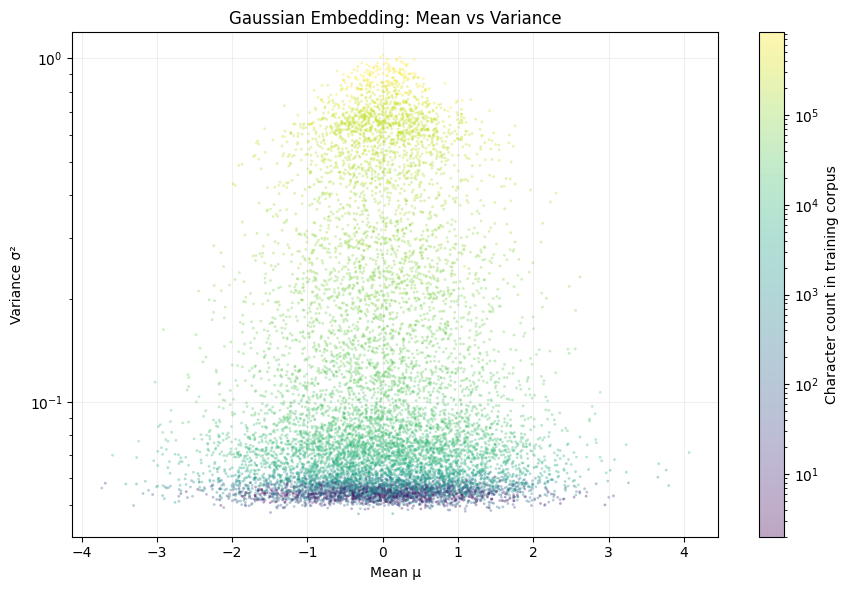

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mu = model.embedding.mu.detach().cpu()
variance = model.embedding.std.detach().square().cpu()

# Give each of a character's embedding dimensions the same frequency colour.
counts = torch.bincount(tokens, minlength=mu.shape[0]).cpu()
point_counts = counts.repeat_interleave(mu.shape[1])

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    mu.flatten().numpy(),
    variance.flatten().numpy(),
    c=point_counts.numpy(),
    cmap="viridis",
    norm=LogNorm(vmin=max(1, counts.min().item()), vmax=counts.max().item()),
    s=4,
    alpha=0.35,
    linewidths=0,
)

ax.set_yscale("log")
ax.set_xlabel("Mean μ")
ax.set_ylabel("Variance σ²")
ax.set_title("Gaussian Embedding: Mean vs Variance")
ax.grid(alpha=0.2)
fig.colorbar(points, ax=ax, label="Character count in training corpus")
plt.tight_layout()
plt.show()

In [ ]:
# Fixed blocks make results more comparable across checkpoints.
eval_generator = torch.Generator().manual_seed(1234)
eval_indices = torch.randperm(
    len(dataset), generator=eval_generator
)[:min(64, len(dataset))].tolist()
eval_blocks = torch.stack([dataset[i] for i in eval_indices])

@torch.no_grad()
def reconstruction_diagnostics(
    blocks=eval_blocks,
    timesteps=(1, 10, 100, 250, 500, 750, 1000),
):
    was_training = model.training
    model.eval()
    try:
        ids = blocks.to(device)
        x0 = model.embedding.sample(ids)
        results = []

        for timestep in timesteps:
            t = torch.full(
                (ids.size(0),), timestep, device=device, dtype=torch.long
            )
            prediction = model(q_sample(x0, t), t)
            mse = F.mse_loss(prediction, x0).item()
            accuracy = (
                model.round_to_tokens(prediction) == ids
            ).float().mean().item()
            results.append((timestep, mse, accuracy))

        return results
    finally:
        model.train(was_training)

for t, mse, accuracy in reconstruction_diagnostics():
    print(f"t={t:4d} | mse={mse:.4f} | token_accuracy={accuracy:.1%}")

t=   1 | mse=0.0717 | token_accuracy=100.0%
t=  10 | mse=0.0706 | token_accuracy=100.0%
t= 100 | mse=0.1425 | token_accuracy=100.0%
t= 250 | mse=0.3472 | token_accuracy=99.7%
t= 500 | mse=0.7645 | token_accuracy=55.6%
t= 750 | mse=0.9842 | token_accuracy=14.6%
t=1000 | mse=0.9887 | token_accuracy=13.3%


In [ ]:
@torch.no_grad()
def trace_reverse(start_noise, reverse_steps=10):
    was_training = model.training
    model.eval()
    try:
        x_t = start_noise.clone()
        previous_output = None
        times = torch.linspace(
            DIFFUSION_STEPS, 0, reverse_steps + 1, device=device
        ).long()

        for step, (current, next_time) in enumerate(
            zip(times[:-1], times[1:])
        ):
            t = torch.full(
                (x_t.size(0),), int(current.item()),
                device=device, dtype=torch.long
            )
            output = model(x_t, t)  # Predicted clean x0

            norm = output.square().mean(dim=(1, 2))
            distance = (
                None if previous_output is None
                else (output - previous_output).square().mean(dim=(1, 2))
            )
            decoded = model.round_to_tokens(output).cpu()

            print(
                f"\nstep {step} | t={current.item()} → {next_time.item()}"
            )
            for i, block in enumerate(decoded):
                change = "—" if distance is None else f"{distance[i].item():.6f}"
                characters = "".join(itos[token.item()] for token in block)
                print(
                    f"sample {i} | output_mse_norm={norm[i].item():.6f}"
                    f" | output_mse_from_previous={change}"
                    f" | {characters!r}"
                )

            previous_output = output

            a_t, a_next = alpha_bar[current], alpha_bar[next_time]
            eps_hat = (
                x_t - a_t.sqrt() * output
            ) / (1 - a_t).sqrt().clamp_min(1e-8)
            x_t = a_next.sqrt() * output + (1 - a_next).sqrt() * eps_hat
    finally:
        model.train(was_training)

# Use reproducible starting noise for this trace.
trace_generator = torch.Generator().manual_seed(1234)
start_noise = torch.randn(SAMPLE_BATCH_SIZE, BLOCK_SIZE, DIM, generator=trace_generator).to(device)
trace_reverse(start_noise, reverse_steps=50)


step 0 | t=1000 → 980
sample 0 | output_mse_norm=0.000342 | output_mse_from_previous=— | '  e     ee  e    e  e       e    e  e  e e   e      e   e ee e  '
sample 1 | output_mse_norm=0.000401 | output_mse_from_previous=— | ' ee e e   eee   e      e      e ee ee     e   e   eeee    eee   '

step 1 | t=980 → 960
sample 0 | output_mse_norm=0.000322 | output_mse_from_previous=0.000002 | '  e     ee  e    e  e       e    e  e  e e   e      e   e ee e  '
sample 1 | output_mse_norm=0.000368 | output_mse_from_previous=0.000004 | ' ee e e   ee    e      e      e ee ee     e   e   eeee    e e   '

step 2 | t=960 → 940
sample 0 | output_mse_norm=0.000311 | output_mse_from_previous=0.000003 | '  e     ee ee    e  e       e  e e  e  e e   e      e e e ee e  '
sample 1 | output_mse_norm=0.000353 | output_mse_from_previous=0.000003 | ' ee e e   eee   e      e     ee ee ee     e   e   eeeee   eee   '

step 3 | t=940 → 920
sample 0 | output_mse_norm=0.000345 | output_mse_from_previous=0.000005 | 'e e 

In [ ]:
checkpoint_path = Path("checkpoints/gauss_embed_dlm_wass_5m.pt")
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "chars": chars,
    "dim": DIM,
}, checkpoint_path)

print(f"Saved {checkpoint_path.resolve()}")

Saved /Users/harrisonfagan/Documents/Projects/DLMs/checkpoints/gauss_embed_dlm_wass_5m.pt
